In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [2]:
df = pd.read_csv("risk_factors_cervical_cancer.csv")

In [3]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [4]:
df.tail()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.0,0.0,...,?,?,0,0,0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,1,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,0,0
857,29,2.0,20.0,1.0,0.0,0.0,0.0,1.0,0.5,0.0,...,?,?,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [6]:
df.describe(percentiles=[0.1,0.25,0.5,0.75,0.9,1])

,Age,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.087413,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,0.302545,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
90%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100%,84.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.dtypes

Age                                    int64
Number of sexual partners             object
First sexual intercourse              object
Num of pregnancies                    object
Smokes                                object
Smokes (years)                        object
Smokes (packs/year)                   object
Hormonal Contraceptives               object
Hormonal Contraceptives (years)       object
IUD                                   object
IUD (years)                           object
STDs                                  object
STDs (number)                         object
STDs:condylomatosis                   object
STDs:cervical condylomatosis          object
STDs:vaginal condylomatosis           object
STDs:vulvo-perineal condylomatosis    object
STDs:syphilis                         object
STDs:pelvic inflammatory disease      object
STDs:genital herpes                   object
STDs:molluscum contagiosum            object
STDs:AIDS                             object
STDs:HIV  

In [8]:
df.shape

(858, 36)

In [9]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [10]:
df.nunique()

Age                                   44
Number of sexual partners             13
First sexual intercourse              22
Num of pregnancies                    12
Smokes                                 3
Smokes (years)                        31
Smokes (packs/year)                   63
Hormonal Contraceptives                3
Hormonal Contraceptives (years)       41
IUD                                    3
IUD (years)                           27
STDs                                   3
STDs (number)                          6
STDs:condylomatosis                    3
STDs:cervical condylomatosis           2
STDs:vaginal condylomatosis            3
STDs:vulvo-perineal condylomatosis     3
STDs:syphilis                          3
STDs:pelvic inflammatory disease       3
STDs:genital herpes                    3
STDs:molluscum contagiosum             3
STDs:AIDS                              2
STDs:HIV                               3
STDs:Hepatitis B                       3
STDs:HPV        

<Axes: ylabel='Frequency'>

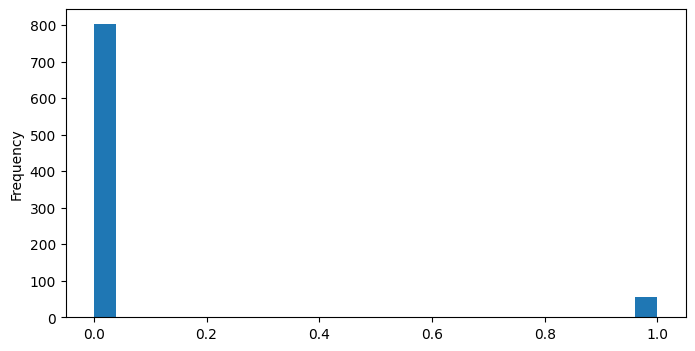

In [11]:
df['Biopsy'].plot.hist(bins=25,figsize=(8,4))

In [12]:
df['Smokes'].value_counts()

Smokes
0.0    722
1.0    123
?       13
Name: count, dtype: int64

In [13]:
for row in df.columns:
    print(f'{row}: {df[row].value_counts()}')

Age: Age
23    54
18    50
21    46
20    45
19    44
25    39
24    39
26    38
28    37
30    35
17    35
27    33
29    33
22    30
35    29
33    28
31    27
34    24
36    24
16    23
15    21
32    18
37    17
41    13
40    12
39     9
38     9
44     6
42     6
45     6
14     5
43     5
46     3
52     2
49     2
48     2
70     2
51     1
59     1
79     1
47     1
84     1
13     1
50     1
Name: count, dtype: int64
Number of sexual partners: Number of sexual partners
2.0     272
3.0     208
1.0     206
4.0      78
5.0      44
?        26
6.0       9
7.0       7
8.0       4
15.0      1
10.0      1
28.0      1
9.0       1
Name: count, dtype: int64
First sexual intercourse: First sexual intercourse
15.0    163
17.0    151
18.0    137
16.0    121
14.0     79
19.0     60
20.0     37
13.0     25
21.0     20
23.0      9
22.0      9
?         7
26.0      7
27.0      6
12.0      6
24.0      6
29.0      5
28.0      3
25.0      2
11.0      2
10.0      2
32.0      1
Name: count, dtype:

In [14]:
df.replace('?', np.nan, inplace=True)

In [15]:
for row in df.columns:
    print(f'{row}: {df[row].value_counts()}')

Age: Age
23    54
18    50
21    46
20    45
19    44
25    39
24    39
26    38
28    37
30    35
17    35
27    33
29    33
22    30
35    29
33    28
31    27
34    24
36    24
16    23
15    21
32    18
37    17
41    13
40    12
39     9
38     9
44     6
42     6
45     6
14     5
43     5
46     3
52     2
49     2
48     2
70     2
51     1
59     1
79     1
47     1
84     1
13     1
50     1
Name: count, dtype: int64
Number of sexual partners: Number of sexual partners
2.0     272
3.0     208
1.0     206
4.0      78
5.0      44
6.0       9
7.0       7
8.0       4
15.0      1
10.0      1
28.0      1
9.0       1
Name: count, dtype: int64
First sexual intercourse: First sexual intercourse
15.0    163
17.0    151
18.0    137
16.0    121
14.0     79
19.0     60
20.0     37
13.0     25
21.0     20
23.0      9
22.0      9
26.0      7
27.0      6
12.0      6
24.0      6
29.0      5
28.0      3
25.0      2
11.0      2
10.0      2
32.0      1
Name: count, dtype: int64
Num of pregnancie

In [16]:
df.isna().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [17]:
convert_obj_to_num = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)','STDs:condylomatosis','STDs:cervical condylomatosis','STDs:vaginal condylomatosis','STDs:vulvo-perineal condylomatosis','STDs:syphilis','STDs:pelvic inflammatory disease','STDs:genital herpes','STDs:molluscum contagiosum','STDs:AIDS','STDs:HIV','STDs:Hepatitis B','STDs:HPV','STDs: Time since first diagnosis','STDs: Time since last diagnosis'] 

In [18]:
df[convert_obj_to_num] = df[convert_obj_to_num].apply(pd.to_numeric, errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [20]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,845.000000,750.000000,750.000000,741.000000,...,71.000000,71.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,...,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,...,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
df['Hormonal Contraceptives'].value_counts()

Hormonal Contraceptives
1.0    481
0.0    269
Name: count, dtype: int64

In [22]:
df['IUD'].value_counts()

IUD
0.0    658
1.0     83
Name: count, dtype: int64

In [23]:
#sns.pairplot(df)

In [24]:
df.corr()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
Age,1.000000,0.085634,0.370017,0.548856,0.056139,0.218619,0.131946,0.068607,0.289783,0.280942,...,0.405929,0.485121,0.110340,0.061443,0.101722,0.092635,-0.003967,0.103283,-0.016862,0.055956
Number of sexual partners,0.085634,1.000000,-0.150169,0.079081,0.249441,0.186932,0.182067,0.006738,0.019569,0.031683,...,0.051825,0.077992,0.022316,0.015694,0.027273,0.022992,-0.039847,-0.008967,0.021858,-0.001442
First sexual intercourse,0.370017,-0.150169,1.000000,-0.060733,-0.124642,-0.058834,-0.056755,0.019436,0.008308,-0.022450,...,0.063774,0.089370,0.067289,-0.032628,0.043970,0.035755,-0.016549,0.003495,-0.010973,0.007264
Num of pregnancies,0.548856,0.079081,-0.060733,1.000000,0.084171,0.180331,0.100904,0.156730,0.224790,0.219104,...,0.216764,0.276249,0.035149,0.010985,0.046788,0.021336,0.040439,0.092017,-0.030036,0.046416
Smokes,0.056139,0.249441,-0.124642,0.084171,1.000000,0.723128,0.493361,-0.002298,0.047588,-0.056232,...,0.072493,0.079909,-0.011342,-0.042825,0.012558,-0.069042,0.035021,0.054322,-0.003957,0.029356
Smokes (years),0.218619,0.186932,-0.058834,0.180331,0.723128,1.000000,0.724116,-0.011571,0.050979,0.029413,...,0.159106,0.164345,0.056234,-0.030968,0.058847,-0.049926,0.072251,0.095890,-0.006827,0.062044
Smokes (packs/year),0.131946,0.182067,-0.056755,0.100904,0.493361,0.724116,1.000000,0.006049,0.041278,0.008277,...,0.195085,0.199611,0.111572,-0.021128,0.113516,-0.034063,0.027044,0.018191,0.004666,0.024882
Hormonal Contraceptives,0.068607,0.006738,0.019436,0.156730,-0.002298,-0.011571,0.006049,1.000000,0.448574,0.034004,...,0.077391,0.132553,0.026447,-0.003536,0.039175,-0.001801,0.033654,-0.004276,-0.011317,0.007750
Hormonal Contraceptives (years),0.289783,0.019569,0.008308,0.224790,0.047588,0.050979,0.041278,0.448574,1.000000,0.099001,...,0.317807,0.361243,0.054712,0.003273,0.063229,-0.013446,0.038945,0.079247,0.076263,0.079388
IUD,0.280942,0.031683,-0.022450,0.219104,-0.056232,0.029413,0.008277,0.034004,0.099001,1.000000,...,0.176076,0.206584,0.110728,0.063405,0.059900,0.152086,0.044821,0.085748,0.007628,0.053194


In [25]:
df['STDs:cervical condylomatosis'].value_counts()  

STDs:cervical condylomatosis
0.0    753
Name: count, dtype: int64

In [26]:
df['STDs:AIDS'].value_counts()

STDs:AIDS
0.0    753
Name: count, dtype: int64

In [27]:
df['STDs:cervical condylomatosis'].isna().sum()

np.int64(105)

In [28]:
df['STDs:AIDS'].isna().sum()

np.int64(105)

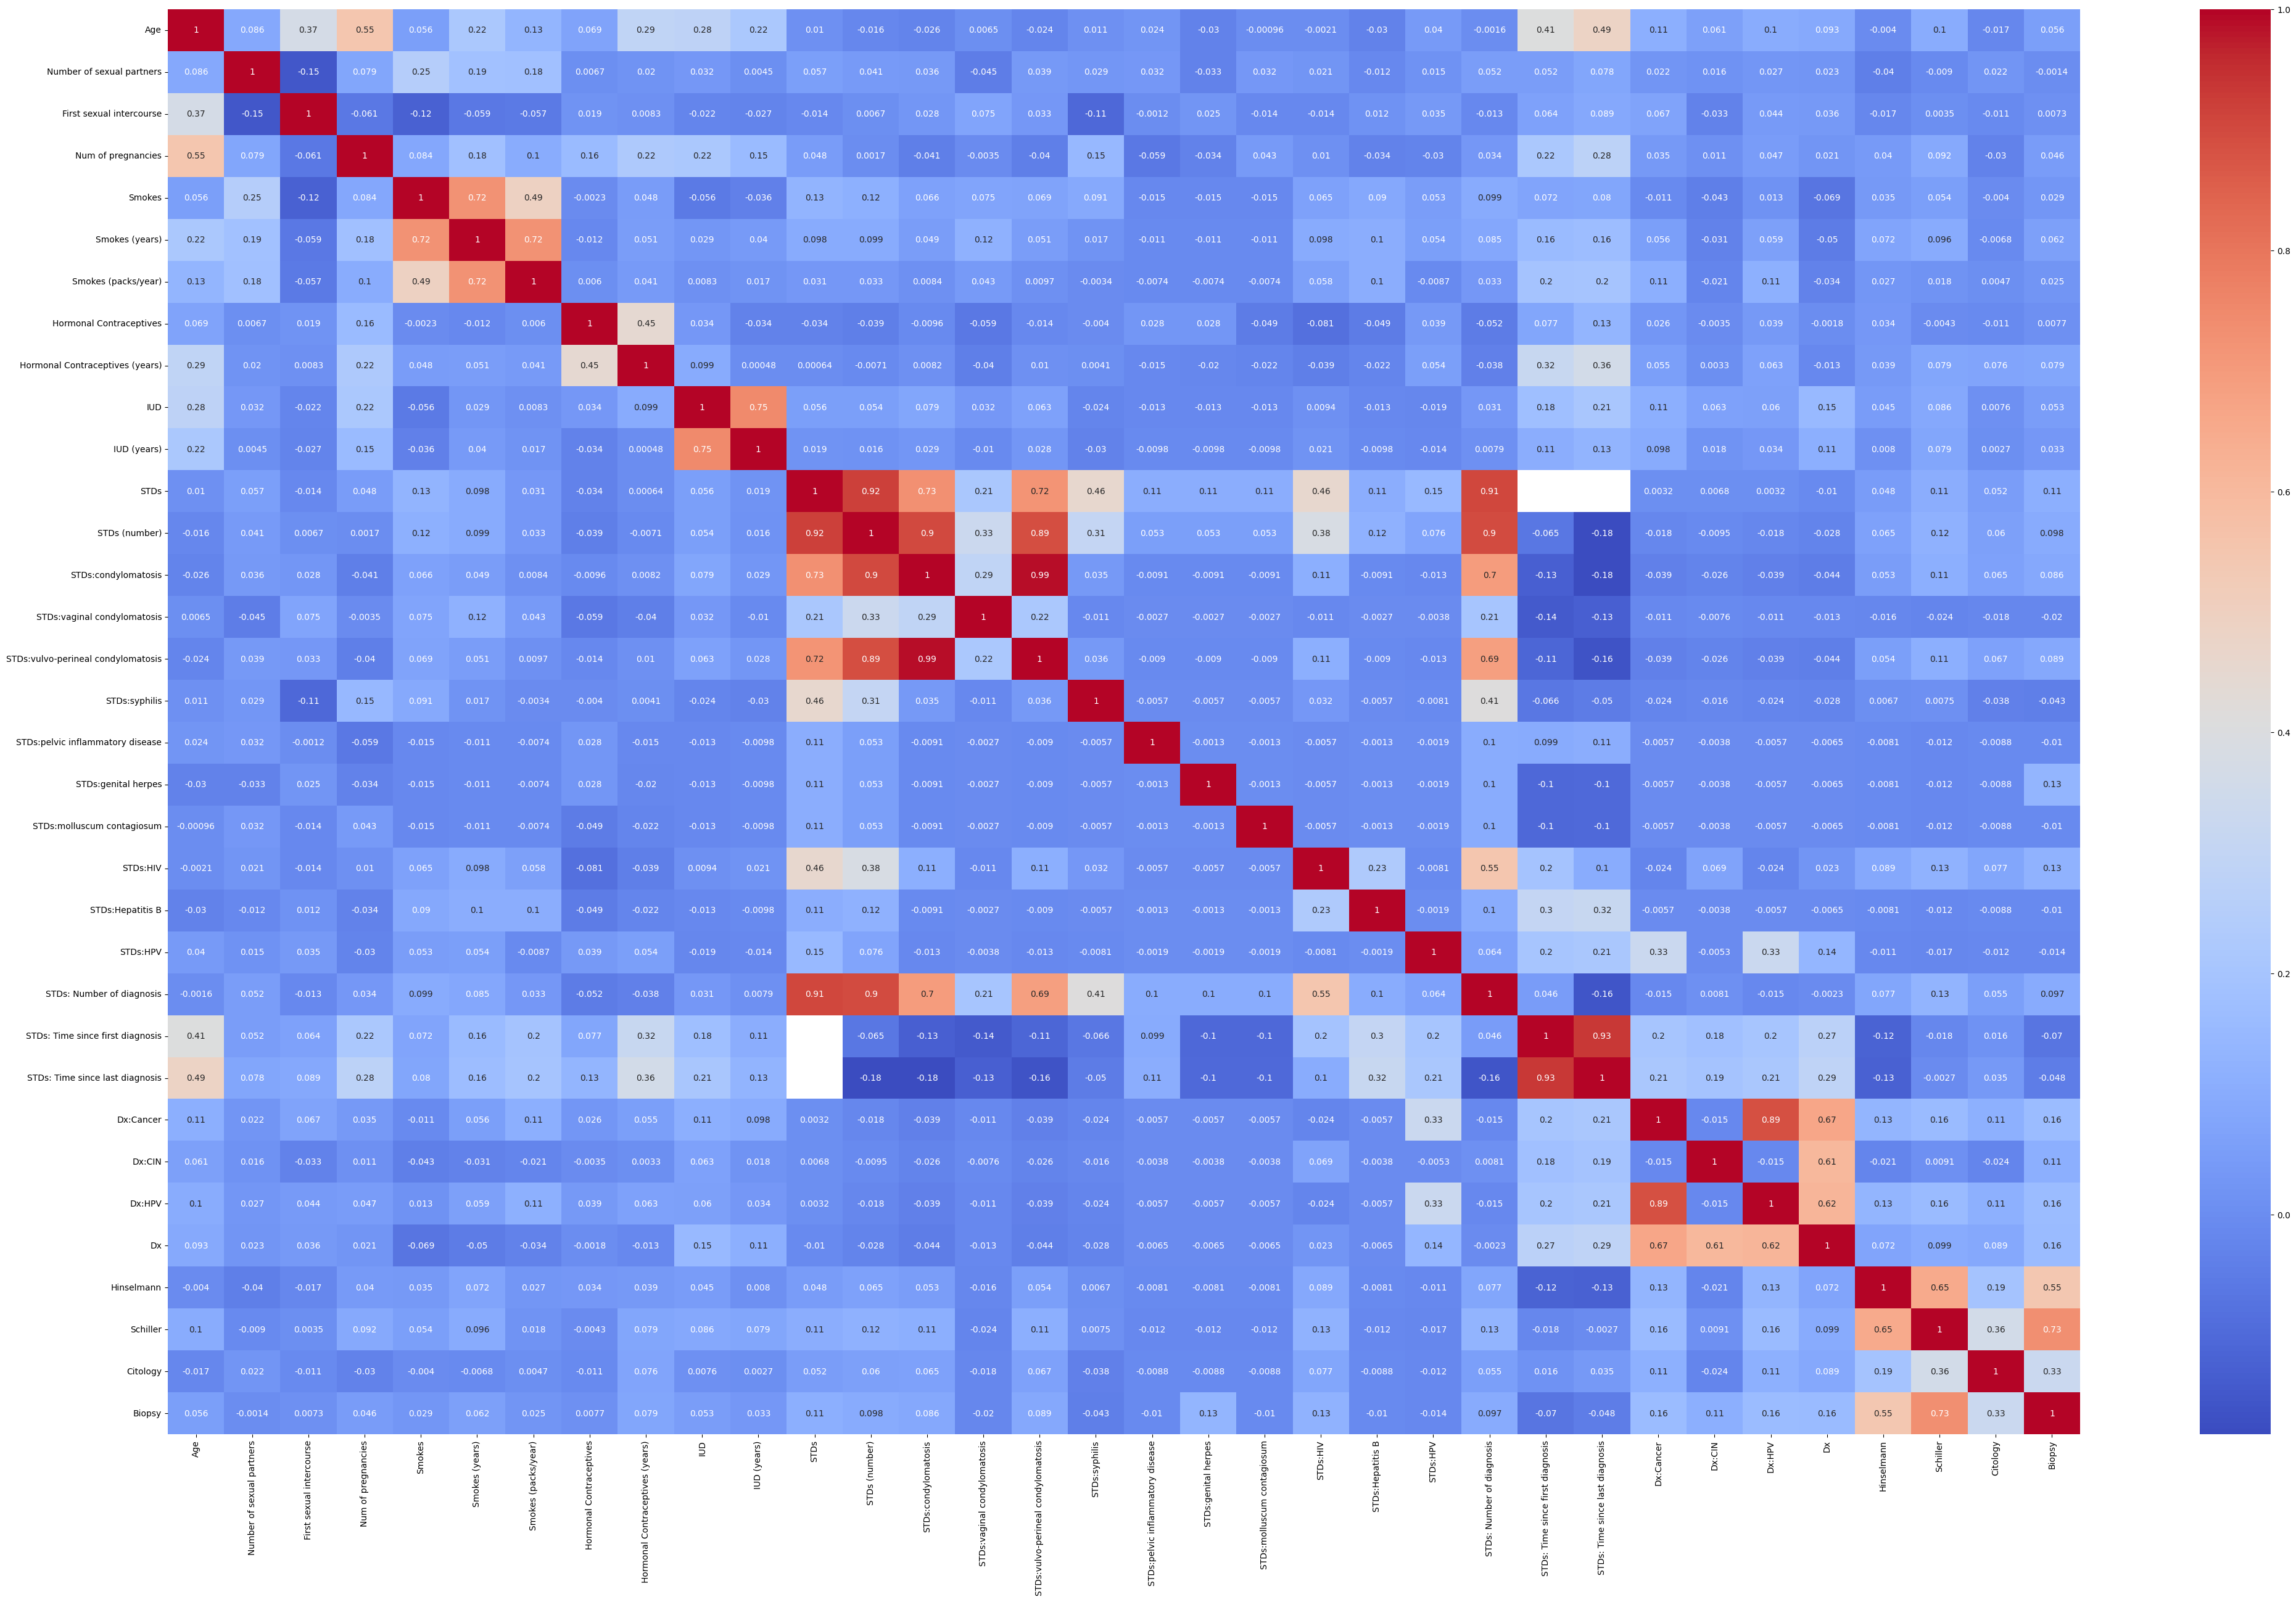

In [29]:
# List of columns that have zero variance
cols_to_drop = ['STDs:cervical condylomatosis', 'STDs:AIDS']

# Drop them in place
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Now plot your heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(50,30))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
df.isna().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:HIV                              105
STDs:Hepatitis B                      105
STDs:HPV                              105
STDs: Number of diagnosis         

In [31]:
df.duplicated().sum() 

np.int64(23)

In [32]:
df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0


In [33]:
cols_to_drop_missing = ['STDs: Time since first diagnosis','STDs: Time since last diagnosis']
df.drop(cols_to_drop_missing, axis=1, inplace=True)

In [34]:
import math

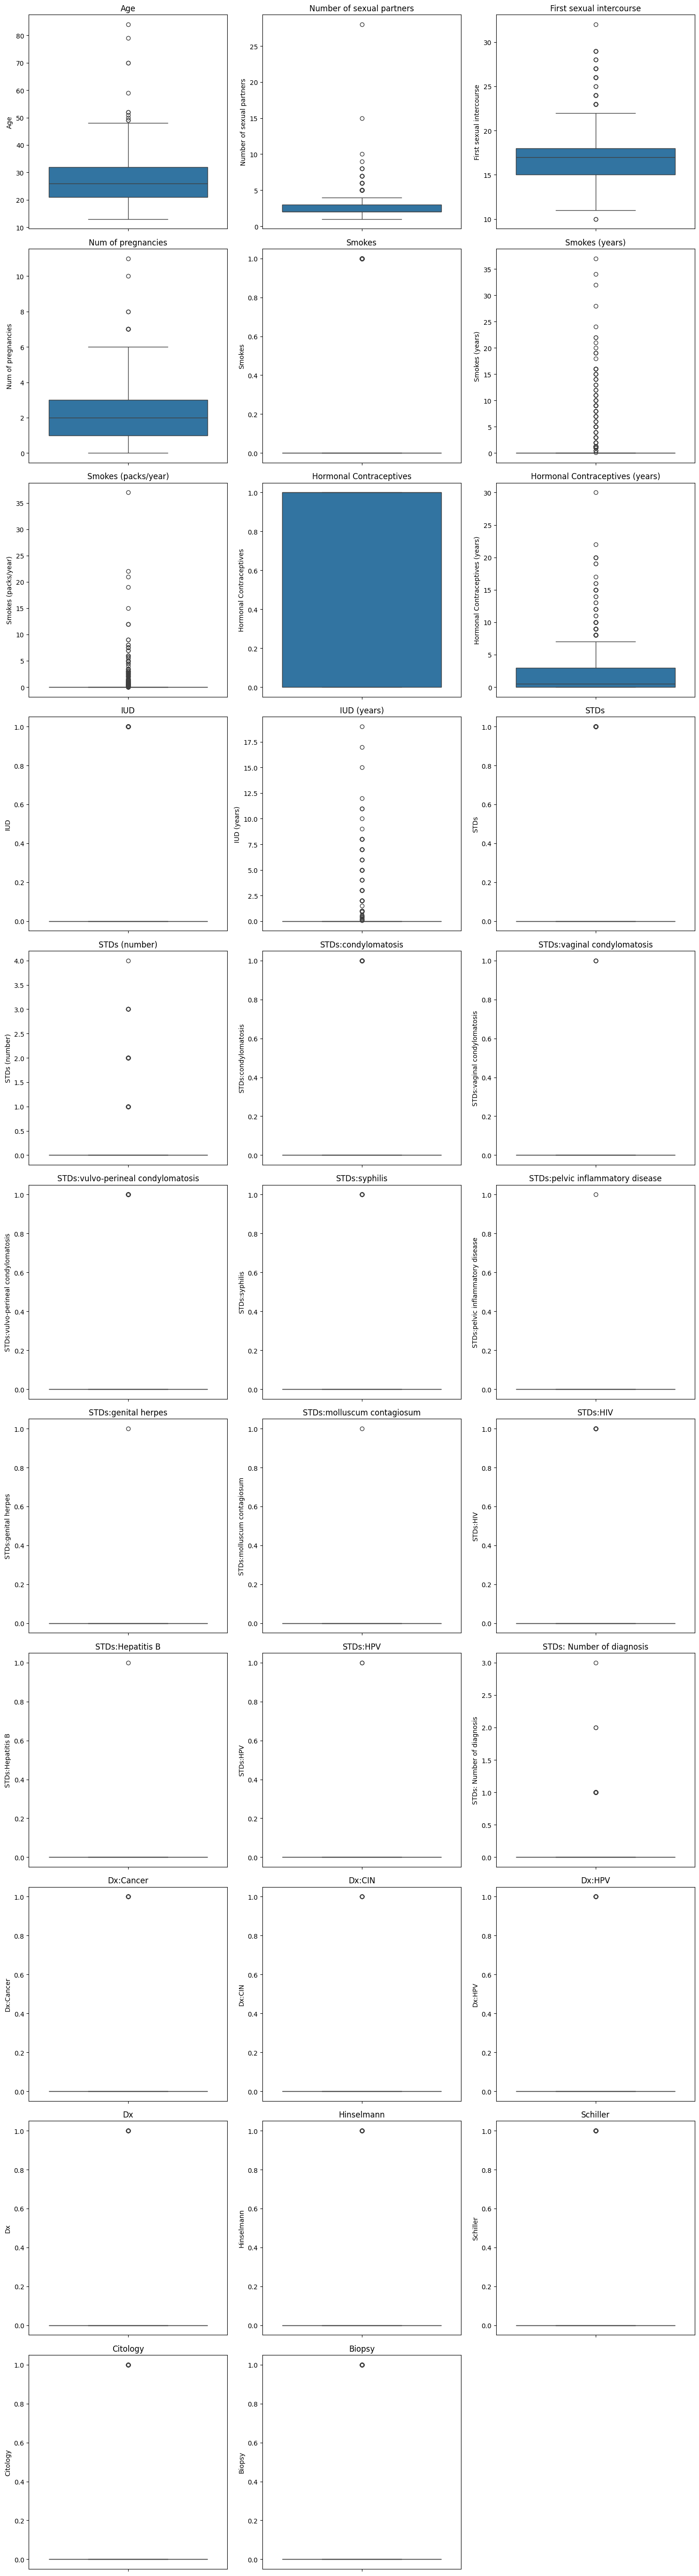

In [35]:

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_plots = len(numeric_cols)
cols = 3  # Number of columns in the grid
rows = math.ceil(num_plots / cols)

# 3. Create the figure
plt.figure(figsize=(15, 5 * rows))  # Adjust height based on number of rows

# 4. Loop through and plot each column
for i, column in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[column])  # y= ensures vertical boxplots
    plt.title(column)
    plt.tight_layout()

plt.show()

In [36]:
df.mean(numeric_only=True)


Age                                   27.023952
Number of sexual partners              2.551852
First sexual intercourse              17.020531
Num of pregnancies                     2.304236
Smokes                                 0.149635
Smokes (years)                         1.253850
Smokes (packs/year)                    0.465823
Hormonal Contraceptives                0.651639
Hormonal Contraceptives (years)        2.302916
IUD                                    0.114799
IUD (years)                            0.527621
STDs                                   0.107483
STDs (number)                          0.180952
STDs:condylomatosis                    0.059864
STDs:vaginal condylomatosis            0.005442
STDs:vulvo-perineal condylomatosis     0.058503
STDs:syphilis                          0.024490
STDs:pelvic inflammatory disease       0.001361
STDs:genital herpes                    0.001361
STDs:molluscum contagiosum             0.001361
STDs:HIV                               0

In [37]:
df.median(numeric_only=True)

Age                                   26.0
Number of sexual partners              2.0
First sexual intercourse              17.0
Num of pregnancies                     2.0
Smokes                                 0.0
Smokes (years)                         0.0
Smokes (packs/year)                    0.0
Hormonal Contraceptives                1.0
Hormonal Contraceptives (years)        0.5
IUD                                    0.0
IUD (years)                            0.0
STDs                                   0.0
STDs (number)                          0.0
STDs:condylomatosis                    0.0
STDs:vaginal condylomatosis            0.0
STDs:vulvo-perineal condylomatosis     0.0
STDs:syphilis                          0.0
STDs:pelvic inflammatory disease       0.0
STDs:genital herpes                    0.0
STDs:molluscum contagiosum             0.0
STDs:HIV                               0.0
STDs:Hepatitis B                       0.0
STDs:HPV                               0.0
STDs: Numbe

In [38]:
df.mode().iloc[0]

Age                                   23.0
Number of sexual partners              2.0
First sexual intercourse              15.0
Num of pregnancies                     1.0
Smokes                                 0.0
Smokes (years)                         0.0
Smokes (packs/year)                    0.0
Hormonal Contraceptives                1.0
Hormonal Contraceptives (years)        0.0
IUD                                    0.0
IUD (years)                            0.0
STDs                                   0.0
STDs (number)                          0.0
STDs:condylomatosis                    0.0
STDs:vaginal condylomatosis            0.0
STDs:vulvo-perineal condylomatosis     0.0
STDs:syphilis                          0.0
STDs:pelvic inflammatory disease       0.0
STDs:genital herpes                    0.0
STDs:molluscum contagiosum             0.0
STDs:HIV                               0.0
STDs:Hepatitis B                       0.0
STDs:HPV                               0.0
STDs: Numbe

In [39]:
df.min(numeric_only=True)

Age                                   13.0
Number of sexual partners              1.0
First sexual intercourse              10.0
Num of pregnancies                     0.0
Smokes                                 0.0
Smokes (years)                         0.0
Smokes (packs/year)                    0.0
Hormonal Contraceptives                0.0
Hormonal Contraceptives (years)        0.0
IUD                                    0.0
IUD (years)                            0.0
STDs                                   0.0
STDs (number)                          0.0
STDs:condylomatosis                    0.0
STDs:vaginal condylomatosis            0.0
STDs:vulvo-perineal condylomatosis     0.0
STDs:syphilis                          0.0
STDs:pelvic inflammatory disease       0.0
STDs:genital herpes                    0.0
STDs:molluscum contagiosum             0.0
STDs:HIV                               0.0
STDs:Hepatitis B                       0.0
STDs:HPV                               0.0
STDs: Numbe

In [40]:
df.max(numeric_only=True)

Age                                   84.0
Number of sexual partners             28.0
First sexual intercourse              32.0
Num of pregnancies                    11.0
Smokes                                 1.0
Smokes (years)                        37.0
Smokes (packs/year)                   37.0
Hormonal Contraceptives                1.0
Hormonal Contraceptives (years)       30.0
IUD                                    1.0
IUD (years)                           19.0
STDs                                   1.0
STDs (number)                          4.0
STDs:condylomatosis                    1.0
STDs:vaginal condylomatosis            1.0
STDs:vulvo-perineal condylomatosis     1.0
STDs:syphilis                          1.0
STDs:pelvic inflammatory disease       1.0
STDs:genital herpes                    1.0
STDs:molluscum contagiosum             1.0
STDs:HIV                               1.0
STDs:Hepatitis B                       1.0
STDs:HPV                               1.0
STDs: Numbe

In [41]:
df.sum(numeric_only=True)

Age                                   22565.000000
Number of sexual partners              2067.000000
First sexual intercourse              14093.000000
Num of pregnancies                     1795.000000
Smokes                                  123.000000
Smokes (years)                         1030.664594
Smokes (packs/year)                     382.906638
Hormonal Contraceptives                 477.000000
Hormonal Contraceptives (years)        1685.734401
IUD                                      83.000000
IUD (years)                             381.470000
STDs                                     79.000000
STDs (number)                           133.000000
STDs:condylomatosis                      44.000000
STDs:vaginal condylomatosis               4.000000
STDs:vulvo-perineal condylomatosis       43.000000
STDs:syphilis                            18.000000
STDs:pelvic inflammatory disease          1.000000
STDs:genital herpes                       1.000000
STDs:molluscum contagiosum     

In [42]:
Q1 = df.quantile(0.25, numeric_only=True)
print( Q1)

Age                                   21.0
Number of sexual partners              2.0
First sexual intercourse              15.0
Num of pregnancies                     1.0
Smokes                                 0.0
Smokes (years)                         0.0
Smokes (packs/year)                    0.0
Hormonal Contraceptives                0.0
Hormonal Contraceptives (years)        0.0
IUD                                    0.0
IUD (years)                            0.0
STDs                                   0.0
STDs (number)                          0.0
STDs:condylomatosis                    0.0
STDs:vaginal condylomatosis            0.0
STDs:vulvo-perineal condylomatosis     0.0
STDs:syphilis                          0.0
STDs:pelvic inflammatory disease       0.0
STDs:genital herpes                    0.0
STDs:molluscum contagiosum             0.0
STDs:HIV                               0.0
STDs:Hepatitis B                       0.0
STDs:HPV                               0.0
STDs: Numbe

In [43]:
Q3 = df.quantile(0.75, numeric_only=True)
print(Q3)

Age                                   32.0
Number of sexual partners              3.0
First sexual intercourse              18.0
Num of pregnancies                     3.0
Smokes                                 0.0
Smokes (years)                         0.0
Smokes (packs/year)                    0.0
Hormonal Contraceptives                1.0
Hormonal Contraceptives (years)        3.0
IUD                                    0.0
IUD (years)                            0.0
STDs                                   0.0
STDs (number)                          0.0
STDs:condylomatosis                    0.0
STDs:vaginal condylomatosis            0.0
STDs:vulvo-perineal condylomatosis     0.0
STDs:syphilis                          0.0
STDs:pelvic inflammatory disease       0.0
STDs:genital herpes                    0.0
STDs:molluscum contagiosum             0.0
STDs:HIV                               0.0
STDs:Hepatitis B                       0.0
STDs:HPV                               0.0
STDs: Numbe

In [44]:
df.std(numeric_only=True)

Age                                   8.482986
Number of sexual partners             1.676686
First sexual intercourse              2.817000
Num of pregnancies                    1.455817
Smokes                                0.356930
Smokes (years)                        4.140727
Smokes (packs/year)                   2.256273
Hormonal Contraceptives               0.476777
Hormonal Contraceptives (years)       3.794180
IUD                                   0.319000
IUD (years)                           1.965439
STDs                                  0.309937
STDs (number)                         0.568153
STDs:condylomatosis                   0.237396
STDs:vaginal condylomatosis           0.073620
STDs:vulvo-perineal condylomatosis    0.234853
STDs:syphilis                         0.154669
STDs:pelvic inflammatory disease      0.036886
STDs:genital herpes                   0.036886
STDs:molluscum contagiosum            0.036886
STDs:HIV                              0.154669
STDs:Hepatiti

In [45]:
cov_matrix = df.cov()
print(cov_matrix)


                                          Age  Number of sexual partners  \
Age                                 71.961056                   1.016573   
Number of sexual partners            1.016573                   2.811276   
First sexual intercourse             8.661700                  -0.745635   
Num of pregnancies                   6.601046                   0.169917   
Smokes                               0.142287                   0.143736   
Smokes (years)                       7.563134                   1.240103   
Smokes (packs/year)                  2.474463                   0.672824   
Hormonal Contraceptives              0.168683                  -0.007906   
Hormonal Contraceptives (years)      9.211352                   0.072625   
IUD                                  0.768499                   0.014776   
IUD (years)                          3.642820                   0.002645   
STDs                                 0.007007                   0.027699   
STDs (number

In [46]:
X = df.drop(columns=['Dx', 'Biopsy', 
                      'Hinselmann','Schiller','Citology',
                      'Dx:Cancer','Dx:CIN','Dx:HPV'])

y = df['Biopsy']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


In [48]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

In [49]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


In [51]:
model = LogisticRegression(class_weight='balanced')


In [52]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
y_pred = model.predict(X_test)

In [54]:
cnf_matrix = confusion_matrix(y_test,y_pred)
print(cnf_matrix)

[[188  47]
 [  9   7]]


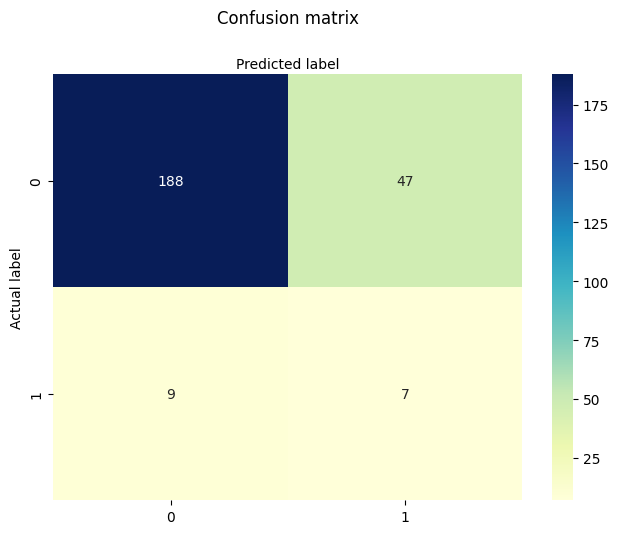

In [55]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [56]:
target_names = ['negative Biopsy', 'Positive Biopsy']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

negative Biopsy       0.95      0.80      0.87       235
Positive Biopsy       0.13      0.44      0.20        16

       accuracy                           0.78       251
      macro avg       0.54      0.62      0.54       251
   weighted avg       0.90      0.78      0.83       251



In [57]:
model.score(X_test,y_test)  

0.7768924302788844

Optimal Threshold: 0.5031
AUC Score: 0.6090


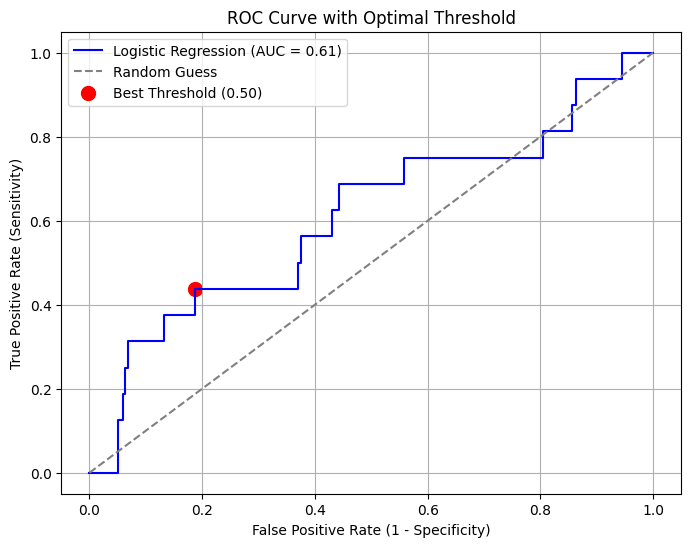

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f"Optimal Threshold: {best_thresh:.4f}")
print(f"AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')


plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', s=100, label=f'Best Threshold ({best_thresh:.2f})')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve with Optimal Threshold')
plt.legend()
plt.grid()
plt.show()

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get the probabilities again
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Apply your specific optimal threshold
threshold = 0.5031
y_pred_optimal = (y_pred_proba >= threshold).astype(int)

# 3. View the final performance
print(f"RESULTS AT THRESHOLD {threshold} ")
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal, target_names=['Negative', 'Positive']))

RESULTS AT THRESHOLD 0.5031 
[[191  44]
 [ 10   6]]
              precision    recall  f1-score   support

    Negative       0.95      0.81      0.88       235
    Positive       0.12      0.38      0.18        16

    accuracy                           0.78       251
   macro avg       0.54      0.59      0.53       251
weighted avg       0.90      0.78      0.83       251



In [65]:
#SVM Model
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#SVM model with balanced class weights,RBF kernel
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

#Train
svm_model.fit(X_train, y_train)

#predictions
y_pred_svm = svm_model.predict(X_test)

#Evaluation
print("Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
target_names = ['negative Biopsy', 'Positive Biopsy']
print(classification_report(y_test, y_pred_svm, target_names=target_names))

Results
Accuracy: 0.8287

Confusion Matrix:
[[204  31]
 [ 12   4]]

Classification Report:
                 precision    recall  f1-score   support

negative Biopsy       0.94      0.87      0.90       235
Positive Biopsy       0.11      0.25      0.16        16

       accuracy                           0.83       251
      macro avg       0.53      0.56      0.53       251
   weighted avg       0.89      0.83      0.86       251



In [ ]:
#GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',  
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Results")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

y_pred_grid = best_svm.predict(X_test)

#Eval
print(f"\nBEST MODEL")
print(f"Accuracy: {accuracy_score(y_test, y_pred_grid):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid, target_names=['Negative', 'Positive']))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Results

Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score (F1): 0.1828

=== BEST MODEL ON TEST SET ===
Accuracy: 0.7092

Confusion Matrix:
[[169  66]
 [  7   9]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.72      0.82       235
    Positive       0.12      0.56      0.20        16

    accuracy                           0.71       251
   macro avg       0.54      0.64      0.51       251
weighted avg       0.91      0.71      0.78       251



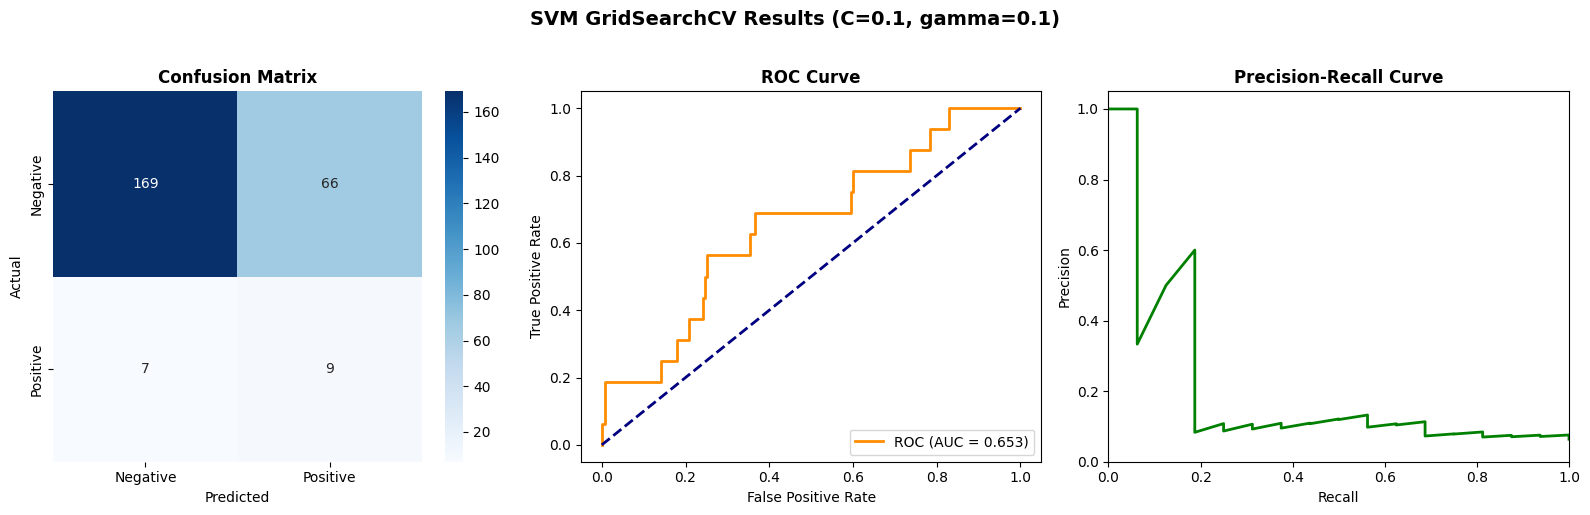


Visualization saved as 'svm_results_clean.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_

y_pred_grid = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_grid)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color='green', lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])

plt.suptitle(f'SVM GridSearchCV Results (C={grid_search.best_params_["C"]}, gamma={grid_search.best_params_["gamma"]})', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('svm_results_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'svm_results_clean.png'")

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# Eval
print("Decision Tree Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
target_names = ['Negative', 'Positive']
print(classification_report(y_test, y_pred_dt, target_names=target_names))

=== Decision Tree Classifier Results ===
Accuracy: 0.8765

Confusion Matrix:
[[215  20]
 [ 11   5]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.91      0.93       235
    Positive       0.20      0.31      0.24        16

    accuracy                           0.88       251
   macro avg       0.58      0.61      0.59       251
weighted avg       0.90      0.88      0.89       251



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

#GridSearchCV
dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid_search.fit(X_train, y_train)

print("\nDECISION TREE GRID SEARCH")
print(f"\nBest Parameters: {dt_grid_search.best_params_}")
print(f"Best CV Score (F1): {dt_grid_search.best_score_:.4f}")

best_dt = dt_grid_search.best_estimator_

y_pred_dt_grid = best_dt.predict(X_test)

#Eval
print(f"\nBEST DECISION TREE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_grid):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_grid, target_names=['Negative', 'Positive']))

Fitting 5 folds for each of 192 candidates, totalling 960 fits

=== DECISION TREE GRID SEARCH RESULTS ===

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV Score (F1): 0.2020

=== BEST DECISION TREE ON TEST SET ===
Accuracy: 0.8884

Confusion Matrix:
[[218  17]
 [ 11   5]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94       235
    Positive       0.23      0.31      0.26        16

    accuracy                           0.89       251
   macro avg       0.59      0.62      0.60       251
weighted avg       0.91      0.89      0.90       251



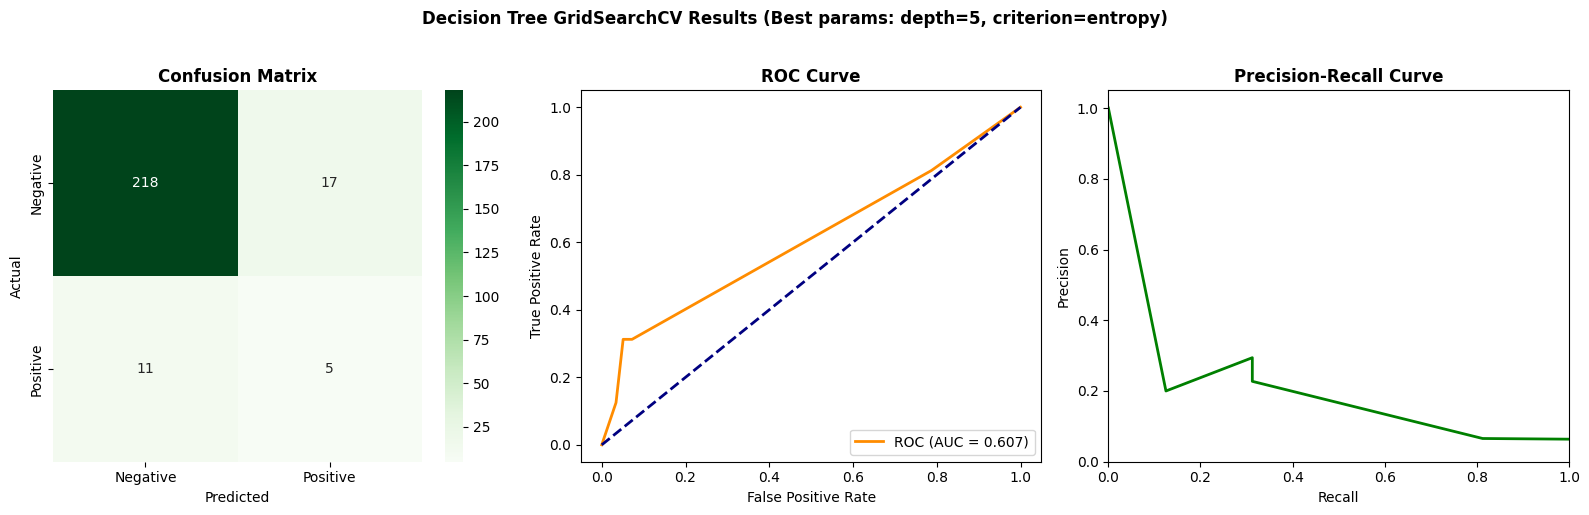


Visualization saved as 'decision_tree_results.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_dt_grid)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_dt)
axes[2].plot(recall, precision, color='green', lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])

plt.suptitle(f'Decision Tree GridSearchCV Results (Best params: depth={dt_grid_search.best_params_["max_depth"]}, criterion={dt_grid_search.best_params_["criterion"]})', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decision_tree_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'decision_tree_results.png'")